In [17]:
import logging
from dataclasses import dataclass
from dataclasses import asdict
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import typer

from qqe.experiments.plotting import plot_training_curves
from qqe.GNN.physics_aware_NN import GNN, Regressor
from qqe.GNN.training.datasets import build_loaders, build_loaders_NN
from qqe.GNN.training.train_config import TrainConfig
from qqe.GNN.training.utils import collect_files_path, evaluate_loss
from qqe.utils import configure_logger

### Training

In [18]:
class GlobalMLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int = 64, dropout_rate: float = 0.0):
        super().__init__()
        dr = float(dropout_rate) if dropout_rate is not None else 0.0
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dr),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, g: torch.Tensor) -> torch.Tensor:
        return self.net(g)

In [3]:
def _resolve_model_save_path(base_path: str, allow_overwrite: bool = False) -> str:
    """Return a non-colliding checkpoint path unless overwrite is explicitly allowed."""
    path = Path(base_path)
    if allow_overwrite or not path.exists():
        return str(path)

    stem = path.stem
    suffix = path.suffix
    parent = path.parent
    counter = 1

    while True:
        candidate = parent / f"{stem}_v{counter}{suffix}"
        if not candidate.exists():
            print(
                "Model checkpoint already exists at %s. Saving to %s instead.",
                path,
                candidate,
            )
            return str(candidate)
        counter += 1

In [4]:
import logging
import sys
import time

from dataclasses import dataclass

import torch
import torch.nn as nn

from torch.amp import GradScaler, autocast
from torch.optim import Adam
from torch_geometric.loader import DataLoader
from tqdm import tqdm

from qqe.GNN.training.utils import evaluate_loss, unpack_supervised_batch

logger = logging.getLogger(__name__)

In [5]:
def _amp_device_type() -> str:
    return "cuda" if torch.cuda.is_available() else "cpu"

def build_loss(loss_type: str, huber_delta: float = 1.0) -> nn.Module:
    loss_type = loss_type.lower()
    if loss_type == "mse":
        return nn.MSELoss()
    if loss_type == "l1":
        return nn.L1Loss()
    if loss_type == "huber":
        return nn.HuberLoss(delta=huber_delta)
    raise ValueError(f"Unsupported loss type: {loss_type}")


@dataclass
class TrainHistory:
    train_loss: list[float]
    val_loss: list[float]
    lr: list[float]

def _run_train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    loss_fn: nn.Module,
    scaler: GradScaler,
    device: torch.device,
    *,
    use_amp: bool = True,
    grad_clip: float | None = 5.0,
    epoch_idx: int = 1,
    num_epochs: int = 1,
    show_progress: bool = True,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
) -> tuple[float, float]:
    model.train()
    amp_device = _amp_device_type()

    total_loss = 0.0
    total_graphs = 0
    batch_count = 0

    start_time = time.time()
    last_heartbeat = start_time

    train_iter = tqdm(
        loader,
        desc=f"Epoch {epoch_idx}/{num_epochs}",
        leave=False,
        disable=not show_progress,
        file=sys.stdout,
    )

    for batch in train_iter:
        model_input, y, batch_size = unpack_supervised_batch(batch, device)

        optimizer.zero_grad(set_to_none=True)

        with autocast(
            device_type=amp_device,
            enabled=(use_amp and device.type == "cuda"),
        ):
            pred = model(model_input).view(-1).float()
            mask = torch.isfinite(y)
            if mask.sum() == 0:
                continue
            loss = loss_fn(pred[mask], y[mask])

        if not torch.isfinite(loss):
            logger.warning("Skipping batch with non-finite loss.")
            continue

        scaler.scale(loss).backward()

        if grad_clip is not None and grad_clip > 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(grad_clip))

        scaler.step(optimizer)
        scaler.update()

        total_loss += float(loss.item()) * batch_size
        total_graphs += batch_size
        batch_count += 1

        running_loss = total_loss / max(1, total_graphs)

        if show_progress:
            train_iter.set_postfix(
                {
                    "loss": f"{running_loss:.4f}",
                    "graphs": total_graphs,
                },
            )

        if log_every_n_batches > 0 and batch_count % log_every_n_batches == 0:
            elapsed = time.time() - start_time
            batches_per_sec = batch_count / max(elapsed, 1e-3)
            remaining_batches = len(loader) - batch_count
            eta_secs = remaining_batches / max(batches_per_sec, 1e-3)

            logger.debug(
                f"Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | "
                f"ETA {eta_secs:.1f}s | {batches_per_sec:.2f} batch/s",
            )

        if heartbeat_secs > 0:
            now = time.time()
            if now - last_heartbeat >= heartbeat_secs:
                elapsed = time.time() - start_time
                print(
                    f"[Heartbeat] Epoch {epoch_idx} batch {batch_count}/{len(loader)} | "
                    f"loss {running_loss:.6f} | elapsed {elapsed:.1f}s | graphs {total_graphs}",
                )
                last_heartbeat = now

    epoch_loss = total_loss / max(1, total_graphs)
    elapsed = time.time() - start_time
    return epoch_loss, elapsed


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    epochs: int = 200,
    lr: float = 1e-3,
    weight_decay: float = 0.0,
    device: str | None = None,
    loss_type: str = "huber",   # "mse" | "huber" | "l1"
    huber_delta: float = 1.0,
    grad_clip: float | None = 5.0,
    early_stopping_patience: int = 15,
    early_stopping_min_delta: float = 0.0,
    use_amp: bool = True,
    scheduler: str = "none",    # "none" | "plateau"
    show_progress: bool = True,
    show_val_progress: bool = False,
    log_every_n_batches: int = 20,
    heartbeat_secs: float = 60.0,
    epoch_time_warning_secs: float = 300.0,
) -> tuple[nn.Module, TrainHistory, torch.device]:
    dev = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    print(f"Using device: {dev}")
    model = model.to(dev)

    loss_fn = build_loss(loss_type=loss_type, huber_delta=huber_delta)
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    if scheduler == "plateau":
        lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=5,
        )
    elif scheduler == "none":
        lr_scheduler = None
    else:
        raise ValueError("scheduler must be 'none' or 'plateau'")

    scaler = GradScaler(
        device=_amp_device_type(),
        enabled=(use_amp and dev.type == "cuda"),
    )

    history = TrainHistory(train_loss=[], val_loss=[], lr=[])

    best_val_loss = float("inf")
    best_state_dict = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        epoch_start_time = time.time()
        print(f"-------- EPOCH {epoch:03d} --------")

        train_loss, train_time = _run_train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            scaler=scaler,
            device=dev,
            use_amp=use_amp,
            grad_clip=grad_clip,
            epoch_idx=epoch,
            num_epochs=epochs,
            show_progress=show_progress,
            log_every_n_batches=log_every_n_batches,
            heartbeat_secs=heartbeat_secs,
        )

        print(f"Training complete ({train_time:.1f}s) | running validation...")

        val_start_time = time.time()
        val_loss = evaluate_loss(
            model=model,
            loader=val_loader,
            device=dev,
            loss_fn=loss_fn,
            use_amp=use_amp,
            show_progress=show_val_progress,
        )
        val_time = time.time() - val_start_time

        if lr_scheduler is not None:
            lr_scheduler.step(val_loss)

        current_lr = float(optimizer.param_groups[0]["lr"])
        history.train_loss.append(float(train_loss))
        history.val_loss.append(float(val_loss))
        history.lr.append(current_lr)

        epoch_time = time.time() - epoch_start_time

        print(
            f"Losses | train {train_loss:.6f} | val {val_loss:.6f} | "
            f"lr {current_lr:.2e} | time train={train_time:.1f}s "
            f"val={val_time:.1f}s total={epoch_time:.1f}s",
        )

        if epoch_time_warning_secs > 0 and epoch_time > epoch_time_warning_secs:
            logger.warning(
                f"Epoch {epoch} took {epoch_time:.1f}s "
                f"(>{epoch_time_warning_secs:.0f}s threshold).",
            )

        improved = val_loss + early_stopping_min_delta < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            bad_epochs = 0
            logger.debug(f"New best validation loss: {best_val_loss:.6f}")
        else:
            bad_epochs += 1
            logger.debug(
                f"No improvement: patience {bad_epochs}/{early_stopping_patience}",
            )
            if bad_epochs >= early_stopping_patience:
                print(
                    f"Early stopping at epoch {epoch:03d} | "
                    f"best val {best_val_loss:.6f} | "
                    f"patience exhausted ({bad_epochs}/{early_stopping_patience})",
                )
                break

    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model, history, dev

In [6]:
def run_training_NN(
    cfg: TrainConfig,
    model_type: str | None = None,
    model_params: dict | None = None,
):
    family_filter = cfg.family if cfg.training_mode == "per_family" else None
    family_projection = cfg.family if cfg.training_mode == "per_family" else None

    VALID_FAMILIES = {"haar", "clifford", "quansistor", "random"}
    if cfg.training_mode == "per_family" and cfg.family not in VALID_FAMILIES:
        raise ValueError(
            f"Invalid family: {cfg.family}. Must be one of {sorted(VALID_FAMILIES)}",
        )
    if cfg.training_mode not in {"global", "per_family"}:
        raise ValueError("training_mode must be 'global' or 'per_family'")
    if cfg.training_mode == "per_family" and cfg.family is None:
        raise ValueError("family must be provided when training_mode='per_family'")

    data_paths = collect_files_path("../outputs/data", family=family_filter)
    if not data_paths:
        raise RuntimeError("No data paths found.")

    train_loader, val_loader, test_loader, global_in_dim, base_dataset = build_loaders_NN(
        data_paths,
        batch_size=cfg.batch_size,
        seed=cfg.seed,
        train_split=cfg.train_split,
        val_split=cfg.val_split,
        global_feature_variant=cfg.global_feature_variant,
        node_feature_variant=cfg.node_feature_backend_variant,
        family_projection=family_projection,
    )
    if model_type == "nn":
        pass
    elif model_type == "MLP":
        model = GlobalMLP(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    elif model_type == "regressor":
        model = Regressor(
            in_dim = global_in_dim,
            hidden_dim = model_params.get("hidden_dim", 128) if model_params else 64,
            dropout_rate = model_params.get("dropout_rate", 0.0) if model_params else 0.0,
        )
    else:
        raise ValueError(f"Unsupported model type: {model_type}")

    model, hist, dev = train_model(
        model,
        train_loader,
        val_loader,
        epochs=cfg.epochs,
        lr=cfg.lr,
        loss_type=cfg.loss_type,
        scheduler="plateau",
        show_progress=cfg.show_progress,
        show_val_progress=cfg.show_val_progress,
        log_every_n_batches=cfg.log_batch_loss_every,
        heartbeat_secs=cfg.heartbeat,
        epoch_time_warning_secs=cfg.epoch_warning,
    )

    loss_fn = build_loss(cfg.loss_type, huber_delta=1.0)
    test_loss = evaluate_loss(
        model,
        test_loader,
        dev,
        loss_fn,
        use_amp=True,
        show_progress=True,
    )

    return model, hist, test_loss, global_in_dim, base_dataset

In [ ]:
def run(
    cfg: TrainConfig,
    model_type: str | None = None,
    model_params: dict | None = None,
):
    model, hist, test_loss, global_in_dim, base_dataset = run_training_NN(cfg, model_type=model_type, model_params=model_params)
    node_in_dim = None
    model_hparams = {
        "gnn_hidden": None,
        "gnn_heads": None,
        "global_hidden": None,
        "reg_hidden": None,
        "num_layers": None,
        "dropout_rate": cfg.dropout_rate if hasattr(cfg, "dropout_rate") else 0.0,
    }

    plot_training_curves(
        hist,
        title=f"{model_type.upper()} SRE regression",
        save_fig=True,
        fig_path=f"outputs/figures/training_curves/training_curves_{model_type}_{loss_type}_{family if training_mode == 'per_family' else 'global'}.png",
    )

    checkpoint = {
        "model_state_dict": model.state_dict(),
        "model_config": {
            "node_in_dim": node_in_dim or None,
            "global_in_dim": global_in_dim,
            "gnn_hidden": model_hparams["gnn_hidden"],
            "gnn_heads": model_hparams["gnn_heads"],
            "global_hidden": model_hparams["global_hidden"],
            "reg_hidden": model_hparams["reg_hidden"],
            "num_layers": model_hparams["num_layers"],
            "dropout_rate": model_hparams["dropout_rate"],
        },
        "train_config": asdict(cfg),
        "feature_config": {
            "global_feature_variant": cfg.global_feature_variant,
            "node_feature_backend_variant": cfg.node_feature_backend_variant,
            "all_gate_keys": getattr(base_dataset, "all_gate_keys", None),
            "family_projection": (
                cfg.family if cfg.training_mode == "per_family" else None
            ),
        },
        "final_metrics": {
            "test_loss": float(test_loss),
        },
    }

    model_save_path = _resolve_model_save_path(
            f"../models/{model_type}_model_{loss_type}_{family if training_mode == 'per_family' else 'global'}.pt",
            allow_overwrite=allow_overwrite,
        )
    torch.save(checkpoint, model_save_path)
    print("Saved model checkpoint to %s", model_save_path)

In [10]:
epochs: int = 40
lr: float = 0.001
loss_type: str = "mse"  # "mse" | "huber" | "l1"
training_mode: str = "global"  # "global" | "per_family"
model_type: str = "nn"  # "gnn" | "nn"
allow_overwrite: bool = False
family: str | None = None #"haar"
target: str = "sre"  # "sre" | "ee"
show_progress: bool = True
show_val_progress: bool = False
log_every_n_batches: int = 5
heartbeat_secs: float = 60.0
epoch_time_warning_secs: float = 300.0

train_config = TrainConfig(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    training_mode=training_mode,
    family=family,
    target=target,
    show_progress=show_progress,
    show_val_progress=show_val_progress,
    log_batch_loss_every=log_every_n_batches,
    heartbeat=heartbeat_secs,
    epoch_warning=epoch_time_warning_secs,
)

Using device: cuda
-------- EPOCH 001 --------
Epoch 1/40:  88%|████████▊ | 3949/4500 [03:00<00:23, 23.58it/s, loss=0.4218, graphs=126464][Heartbeat] Epoch 1 batch 3952/4500 | loss 0.421790 | elapsed 180.1s | graphs 126464
Training complete (205.4s) | running validation...                                         
Losses | train 0.384866 | val 0.112002 | lr 1.00e-03 | time train=205.4s val=20.5s total=226.0s
-------- EPOCH 002 --------
Epoch 2/40:  87%|████████▋ | 3922/4500 [03:00<00:26, 21.62it/s, loss=0.1038, graphs=125600][Heartbeat] Epoch 2 batch 3925/4500 | loss 0.103796 | elapsed 180.1s | graphs 125600
Training complete (206.0s) | running validation...                                         
Losses | train 0.101864 | val 0.069089 | lr 1.00e-03 | time train=206.0s val=20.2s total=226.3s
-------- EPOCH 003 --------
Epoch 3/40:  87%|████████▋ | 3933/4500 [03:00<00:27, 20.94it/s, loss=0.0876, graphs=125952][Heartbeat] Epoch 3 batch 3936/4500 | loss 0.087650 | elapsed 180.1s | graphs 

Epoch 34 took 307.5s (>300s threshold).


Losses | train 0.049798 | val 0.059151 | lr 2.50e-04 | time train=279.0s val=28.6s total=307.5s
-------- EPOCH 035 --------
Epoch 35/40:  90%|████████▉ | 4046/4500 [04:00<00:27, 16.37it/s, loss=0.0495, graphs=129536][Heartbeat] Epoch 35 batch 4048/4500 | loss 0.049496 | elapsed 240.0s | graphs 129536
Training complete (267.8s) | running validation...                                          
Losses | train 0.049735 | val 0.059349 | lr 2.50e-04 | time train=267.8s val=20.3s total=288.0s
-------- EPOCH 036 --------
Epoch 36/40:  86%|████████▌ | 3879/4500 [03:00<00:29, 21.31it/s, loss=0.0494, graphs=124192][Heartbeat] Epoch 36 batch 3881/4500 | loss 0.049376 | elapsed 180.1s | graphs 124192
Training complete (208.8s) | running validation...                                          
Losses | train 0.049635 | val 0.059436 | lr 2.50e-04 | time train=208.8s val=20.6s total=229.3s
-------- EPOCH 037 --------
Epoch 37/40:  86%|████████▌ | 3848/4500 [03:00<00:28, 22.58it/s, loss=0.0498, graphs=1

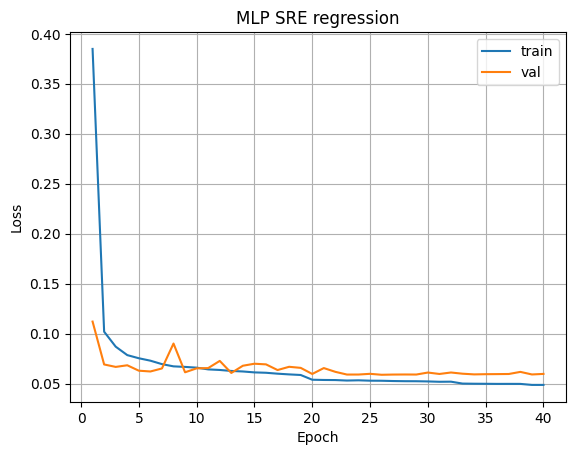

Saved model checkpoint to %s ..\models\MLP_model_mse_global.pt


In [11]:
# GlobalMLP hidden_dim=128, no dropout, mse loss
run(train_config, model_type="MLP", model_params={"hidden_dim": 128, "dropout_rate": 0.0})

In [12]:
epochs: int = 40
lr: float = 0.001
loss_type: str = "huber"  # "mse" | "huber" | "l1"
training_mode: str = "global"  # "global" | "per_family"
model_type: str = "nn"  # "gnn" | "nn"


train_config = TrainConfig(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    training_mode=training_mode,
    family=family,
    target=target,
    show_progress=show_progress,
    show_val_progress=show_val_progress,
    log_batch_loss_every=log_every_n_batches,
    heartbeat=heartbeat_secs,
    epoch_warning=epoch_time_warning_secs,
)

In [13]:
# GlobalMLP hidden_dim=128, 0.1, Huber loss
run(train_config, model_type="MLP", model_params={"hidden_dim": 128, "dropout_rate": 0.1})

Using device: cuda
-------- EPOCH 001 --------
Epoch 1/40:  85%|████████▍ | 3818/4500 [03:00<00:31, 21.52it/s, loss=0.2882, graphs=122208][Heartbeat] Epoch 1 batch 3819/4500 | loss 0.288234 | elapsed 180.1s | graphs 122208
Training complete (212.4s) | running validation...                                         
Losses | train 0.270679 | val 0.224097 | lr 1.00e-03 | time train=212.4s val=20.5s total=233.0s
-------- EPOCH 002 --------
Epoch 2/40:  84%|████████▍ | 3774/4500 [03:00<00:34, 21.23it/s, loss=0.1292, graphs=120864][Heartbeat] Epoch 2 batch 3777/4500 | loss 0.129167 | elapsed 180.1s | graphs 120864
Training complete (214.4s) | running validation...                                         
Losses | train 0.125730 | val 0.064265 | lr 1.00e-03 | time train=214.4s val=20.6s total=235.0s
-------- EPOCH 003 --------
Epoch 3/40:  84%|████████▎ | 3765/4500 [03:00<00:34, 21.54it/s, loss=0.0956, graphs=120512][Heartbeat] Epoch 3 batch 3766/4500 | loss 0.095598 | elapsed 180.1s | graphs 

KeyboardInterrupt: 

In [ ]:
epochs: int = 40
lr: float = 0.001
loss_type: str = "huber"  # "mse" | "huber" | "l1"
training_mode: str = "global"  # "global" | "per_family"
model_type: str = "nn"  # "gnn" | "nn"

train_config = TrainConfig(
    epochs=epochs,
    lr=lr,
    loss_type=loss_type,
    training_mode=training_mode,
    family=family,
    target=target,
    show_progress=show_progress,
    show_val_progress=show_val_progress,
    log_batch_loss_every=log_every_n_batches,
    heartbeat=heartbeat_secs,
    epoch_warning=epoch_time_warning_secs,
)

Using device: cuda
-------- EPOCH 001 --------
Training complete (54.4s) | running validation...                                         
Losses | train 0.792092 | val 0.237705 | lr 1.00e-03 | time train=54.4s val=5.3s total=59.6s
-------- EPOCH 002 --------
Training complete (55.5s) | running validation...                                         
Losses | train 0.118505 | val 0.155189 | lr 1.00e-03 | time train=55.5s val=5.4s total=60.9s
-------- EPOCH 003 --------
Training complete (54.4s) | running validation...                                         
Losses | train 0.094570 | val 0.108907 | lr 1.00e-03 | time train=54.4s val=5.4s total=59.8s
-------- EPOCH 004 --------
Training complete (54.5s) | running validation...                                         
Losses | train 0.077246 | val 0.113539 | lr 1.00e-03 | time train=54.5s val=5.2s total=59.7s
-------- EPOCH 005 --------
Training complete (53.8s) | running validation...                                         
Losses | train

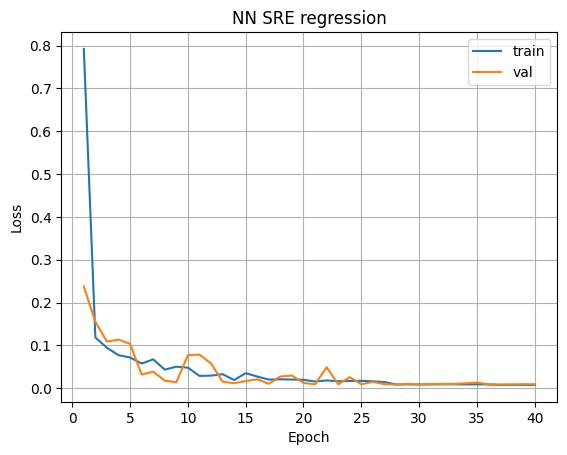

Model checkpoint already exists at %s. Saving to %s instead. ..\models\nn_model_mse_haar.pt ..\models\nn_model_mse_haar_v6.pt
Saved model checkpoint to %s ..\models\nn_model_mse_haar_v6.pt


In [ ]:
# Regressor hidden_dim=128, no dropout, Huber loss
run(train_config, model_type="regressor", model_params={"hidden_dim": 128, "dropout_rate": 0.0})

### Prediction

In [19]:
import csv
import logging

from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import typer

from torch.utils.data import DataLoader as TorchDataLoader
from torch_geometric.loader import DataLoader as PyGDataLoader
from tqdm import tqdm

from qqe.GNN.physics_aware_NN import GNN, QuantumCircuitGraphDataset, Regressor
from qqe.utils import configure_logger

In [33]:
def collect_prediction_paths(dataset_root: str, family: str | None = None) -> list[str]:
    root = Path(dataset_root)
    pred_root = root / "predictions"

    if family is not None:
        paths = sorted((pred_root / family).glob("*.pt"))
    else:
        paths = []
        if pred_root.exists():
            for subdir in sorted(pred_root.iterdir()):
                if subdir.is_dir():
                    paths.extend(sorted(subdir.glob("*.pt")))

    return [str(p.resolve()) for p in paths]


def checkpoint_path(model_kind: str, training_scope: str, family: str | None = None, loss_type: str = "mse") -> Path:
    if model_kind not in {"gnn", "nn"}:
        raise ValueError("model_kind must be 'gnn' or 'nn'")
    if training_scope not in {"global", "family"}:
        raise ValueError("training_scope must be 'global' or 'family'")

    if training_scope == "family":
        if family is None:
            raise ValueError("family must be provided when training_scope='family'")
        return Path(f"models/{model_kind}_model_{loss_type}_{family}.pt")

    return Path(f"models/{model_kind}_model_{loss_type}_global.pt")


def load_checkpoint(path: str | Path) -> tuple[dict[str, Any], dict[str, Any], dict[str, Any]]:
    payload = torch.load(path, map_location="cpu", weights_only=False)

    if not isinstance(payload, dict):
        raise RuntimeError("Checkpoint must be a dict.")

    if "model_state_dict" in payload:
        state_dict = payload["model_state_dict"]
        model_config = payload.get("model_config", {}) or {}
        feature_config = payload.get("feature_config", {}) or {}
    else:
        # older raw state_dict format
        state_dict = payload
        model_config = {}
        feature_config = {}

    return state_dict, model_config, feature_config


def build_model(model_kind: str, model_config: dict[str, Any]) -> torch.nn.Module:
    if model_kind == "gnn":
        return GNN(
            node_in_dim=int(model_config["node_in_dim"]),
            global_in_dim=int(model_config["global_in_dim"]),
            gnn_hidden=int(model_config.get("gnn_hidden", 32)),
            gnn_heads=int(model_config.get("gnn_heads", 8)),
            global_hidden=int(model_config.get("global_hidden", 16)),
            reg_hidden=int(model_config.get("reg_hidden", 16)),
            num_layers=int(model_config.get("num_layers", 5)),
            dropout_rate=float(model_config.get("dropout_rate", 0.1)),
        )

    if model_kind == "nn":
        return Regressor(
            in_dim=int(model_config["global_in_dim"]),
            hidden_dim=int(model_config.get("hidden_dim", 128)),
        )
    
    if model_kind == "MLP":
        return GlobalMLP(
            in_dim = int(model_config["global_in_dim"]),
            hidden_dim = int(model_config.get("hidden_dim", 128)),
            dropout_rate = float(model_config.get("dropout_rate", 0.0)),
        )

    raise ValueError(f"Unsupported model_kind: {model_kind}")

In [39]:
class PredictionGraphWrapper:
    def __init__(
        self,
        dataset,
        target_node_dim: int | None = None,
        target_global_dim: int | None = None,
    ):
        self.dataset = dataset
        self.target_node_dim = target_node_dim
        self.target_global_dim = target_global_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx].clone()

        if self.target_node_dim is not None:
            cur = int(data.x.shape[1])
            if cur < self.target_node_dim:
                data.x = F.pad(data.x, (0, self.target_node_dim - cur))
            elif cur > self.target_node_dim:
                data.x = data.x[:, : self.target_node_dim]

        if hasattr(data, "global_features"):
            g = data.global_features
            if g.dim() > 1:
                g = g.view(-1)

            if self.target_global_dim is not None:
                cur = int(g.shape[0])
                if cur < self.target_global_dim:
                    g = F.pad(g, (0, self.target_global_dim - cur))
                elif cur > self.target_global_dim:
                    g = g[: self.target_global_dim]

            data.global_features = g

        return data


class PredictionTensorWrapper:
    def __init__(self, dataset, target_global_dim: int | None = None):
        self.dataset = dataset
        self.target_global_dim = target_global_dim

    def __len__(self) -> int:
        return len(self.dataset)

    def __getitem__(self, idx: int):
        data = self.dataset[idx]
        g = data.global_features
        if not torch.is_tensor(g):
            g = torch.as_tensor(g, dtype=torch.float32)
        g = g.flatten().to(torch.float32)

        if self.target_global_dim is not None:
            cur = int(g.shape[0])
            if cur < self.target_global_dim:
                g = F.pad(g, (0, self.target_global_dim - cur))
            elif cur > self.target_global_dim:
                g = g[: self.target_global_dim]

        meta = getattr(data, "meta", {}) or {}
        target = extract_target_value(data)
        return g, meta, target


def build_prediction_dataset(
    pt_paths: list[str],
    *,
    global_feature_variant: str,
    node_feature_backend_variant: str | None,
    fixed_all_gate_keys: list[str] | None,
):
    return QuantumCircuitGraphDataset(
        root="qqe/cache/prediction_cache",
        pt_paths=pt_paths,
        global_feature_variant=global_feature_variant,
        node_feature_backend_variant=node_feature_backend_variant,
        fixed_all_gate_keys=fixed_all_gate_keys,
    )


def build_loader(
    model_kind: str,
    dataset,
    *,
    batch_size: int,
    target_node_dim: int | None,
    target_global_dim: int | None,
):
    if model_kind == "gnn":
        wrapped = PredictionGraphWrapper(
            dataset,
            target_node_dim=target_node_dim,
            target_global_dim=target_global_dim,
        )
        return PyGDataLoader(
            wrapped,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )

    if model_kind == "nn" or model_kind == "MLP":
        wrapped = PredictionTensorWrapper(dataset, target_global_dim=target_global_dim)

        def collate_fn(batch):
            xs, metas, targets = zip(*batch)
            return torch.stack(xs, dim=0), list(metas), list(targets)

        return TorchDataLoader(
            wrapped,
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
            collate_fn=collate_fn,
        )

    raise ValueError(f"Unsupported model_kind: {model_kind}")

In [41]:
def extract_target_value(sample: Any) -> float | None:
    y = getattr(sample, "y", None)
    if y is None:
        return None

    if torch.is_tensor(y):
        if y.numel() == 0:
            return None
        value = float(y.flatten()[0].item())
    else:
        value = float(y)

    if not np.isfinite(value):
        return None

    return value

@torch.no_grad()
def predict(
    model: torch.nn.Module,
    loader,
    *,
    model_kind: str,
    device: torch.device,
    show_progress: bool = True,
) -> list[dict[str, Any]]:
    model.eval()
    rows: list[dict[str, Any]] = []
    total_batches = len(loader) if hasattr(loader, "__len__") else None

    if model_kind == "gnn":
        for batch in tqdm(
            loader,
            total=total_batches,
            desc="Predicting (gnn)",
            unit="batch",
            disable=not show_progress,
        ):
            samples = batch.to_data_list()
            batch = batch.to(device)
            preds = model(batch).view(-1).cpu().tolist()

            for sample, pred in zip(samples, preds):
                meta = getattr(sample, "meta", {}) or {}
                target = extract_target_value(sample)
                rows.append(
                    {
                        "cid": meta.get("cid"),
                        "family": meta.get("family"),
                        "seed": meta.get("seed"),
                        "n_qubits": meta.get("n_qubits"),
                        "n_layers": meta.get("n_layers"),
                        "target": target,
                        "prediction": float(pred),
                        "error": abs(float(pred - target)) if target is not None else None,
                    },
                )
        return rows

    if model_kind == "nn" or model_kind == "MLP":
        for x, metas, targets in tqdm(
            loader,
            total=total_batches,
            desc="Predicting (nn)",
            unit="batch",
            disable=not show_progress,
        ):
            x = x.to(device)
            preds = model(x).view(-1).cpu().tolist()

            for meta, pred, target in zip(metas, preds, targets):
                rows.append(
                    {
                        "cid": meta.get("cid"),
                        "family": meta.get("family"),
                        "seed": int(meta.get("seed")),
                        "n_qubits": int(meta.get("n_qubits")),
                        "n_layers": int(meta.get("n_layers")),
                        "target": target,
                        "prediction": float(pred),
                        "error": abs(float(pred - target)) if target is not None else None,
                    },
                )
        return rows

    raise ValueError(f"Unsupported model_kind: {model_kind}")

In [23]:
def save_predictions_csv(rows: list[dict[str, Any]], path: str | Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    fieldnames = ["cid", "family", "seed", "n_qubits", "n_layers", "target", "prediction", "error"]
    with path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    return path


def aggregate_mean_std(
    rows: list[dict[str, Any]],
    *,
    x_key: str,
    fixed_key: str | None = None,
    fixed_value: int | None = None,
) -> list[dict[str, Any]]:
    filtered = rows
    if fixed_key is not None and fixed_value is not None:
        filtered = [r for r in rows if int(r[fixed_key]) == int(fixed_value)]

    groups: dict[int, list[float]] = {}
    for r in filtered:
        x = int(r[x_key])
        groups.setdefault(x, []).append(float(r["prediction"]))

    out = []
    for x in sorted(groups):
        vals = np.asarray(groups[x], dtype=float)
        out.append(
            {
                x_key: x,
                "mean": float(vals.mean()),
                "std": float(vals.std(ddof=0)),
                "n": len(vals),
            },
        )
    return out

In [24]:
def plot_fixed_layers_vary_qubits(
    rows: list[dict[str, Any]],
    *,
    n_layers: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_layers"]) == int(n_layers)]
    if not filtered:
        print("No predictions found for n_layers=%s", n_layers)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                q = int(r["n_qubits"])
                groups.setdefault(q, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[q]) for q in x]
            yerr = [np.std(groups[q], ddof=0) for q in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            q = int(r["n_qubits"])
            groups.setdefault(q, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[q]) for q in x]
        yerr = [np.std(groups[q], ddof=0) for q in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs qubits (n_layers={n_layers})")

    plt.xlabel("Number of qubits")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    plt.show()

def plot_fixed_qubits_vary_layers(
    rows: list[dict[str, Any]],
    *,
    n_qubits: int,
    output_path: str | Path | None = None,
    split_by_family: bool = True,
):
    filtered = [r for r in rows if int(r["n_qubits"]) == int(n_qubits)]
    if not filtered:
        print("No predictions found for n_qubits=%s", n_qubits)
        return

    plt.figure(figsize=(8, 5))

    if split_by_family:
        families = sorted({str(r.get("family", "unknown")) for r in filtered})
        for family in families:
            family_rows = [r for r in filtered if str(r.get("family", "unknown")) == family]

            groups: dict[int, list[float]] = {}
            for r in family_rows:
                L = int(r["n_layers"])
                groups.setdefault(L, []).append(float(r["prediction"]))

            x = sorted(groups.keys())
            y = [np.mean(groups[L]) for L in x]
            yerr = [np.std(groups[L], ddof=0) for L in x]

            plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3, label=family)

        plt.legend(title="family")
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")
    else:
        groups: dict[int, list[float]] = {}
        for r in filtered:
            L = int(r["n_layers"])
            groups.setdefault(L, []).append(float(r["prediction"]))

        x = sorted(groups.keys())
        y = [np.mean(groups[L]) for L in x]
        yerr = [np.std(groups[L], ddof=0) for L in x]

        plt.errorbar(x, y, yerr=yerr, marker="o", linestyle="-", capsize=3)
        plt.title(f"Predicted SRE vs layers (n_qubits={n_qubits})")

    plt.xlabel("Number of layers")
    plt.ylabel("Predicted SRE")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=180)
        plt.close()
    plt.show()

In [29]:
model_path: str = "../models/MLP_model_mse_global.pt"
model_kind: str = "MLP"
training_scope: str = "global"
loss_type: str = "mse"
model_family: str | None = None ###
dataset_root: str = "../outputs/data"
dataset_family: str | None = None ###
batch_size: int = 32
global_feature_variant: str = "binned"
node_feature_backend_variant: str | None = None
plot_n_layers: int = 80
plot_n_qubits: int  = 16
split_by_family: bool = True
show_progress: bool = True

In [30]:
state_dict, model_config, feature_config = load_checkpoint(model_path)

In [35]:
model_config['dropout_rate'] = 0.0

In [36]:
model = build_model(model_kind, model_config)
model.load_state_dict(state_dict, strict=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [37]:
pt_paths = collect_prediction_paths(dataset_root, dataset_family)
if not pt_paths:
    raise RuntimeError("No prediction .pt files found.")

print("Found %d prediction files", len(pt_paths))

Found %d prediction files 270000


In [42]:
dataset = build_prediction_dataset(
    pt_paths,
    global_feature_variant=feature_config.get("global_feature_variant", global_feature_variant),
    node_feature_backend_variant=feature_config.get("node_feature_backend_variant", node_feature_backend_variant),
    fixed_all_gate_keys=feature_config.get("all_gate_keys"),
)

loader = build_loader(
    model_kind,
    dataset,
    batch_size=batch_size,
    target_node_dim=model_config.get("node_in_dim"),
    target_global_dim=model_config.get("global_in_dim"),
)

rows = predict(
    model,
    loader,
    model_kind=model_kind,
    device=device,
    show_progress=show_progress,
)
output_csv = f"../outputs/figures/predictions/{training_scope}/{model_kind}_predictions_{model_family or 'global'}.csv"

save_predictions_csv(rows, output_csv)

Predicting (nn):   0%|          | 0/8438 [00:00<?, ?batch/s]

Predicting (nn): 100%|██████████| 8438/8438 [23:33<00:00,  5.97batch/s]


WindowsPath('../outputs/figures/predictions/global/MLP_predictions_global.csv')

In [43]:
for i in range(5):
    print(f"Sample prediction {i+1}: {rows[i]}")

Sample prediction 1: {'cid': 'clifford_Q10_L100_S1008105898', 'family': 'clifford', 'seed': 1008105898, 'n_qubits': 10, 'n_layers': 100, 'target': 8.003973960876465, 'prediction': 8.087992668151855, 'error': 0.08401870727539062}
Sample prediction 2: {'cid': 'clifford_Q10_L100_S1017900085', 'family': 'clifford', 'seed': 1017900085, 'n_qubits': 10, 'n_layers': 100, 'target': 8.00405216217041, 'prediction': 8.087539672851562, 'error': 0.08348751068115234}
Sample prediction 3: {'cid': 'clifford_Q10_L100_S1032783643', 'family': 'clifford', 'seed': 1032783643, 'n_qubits': 10, 'n_layers': 100, 'target': 8.003904342651367, 'prediction': 8.08994197845459, 'error': 0.08603763580322266}
Sample prediction 4: {'cid': 'clifford_Q10_L100_S1034770690', 'family': 'clifford', 'seed': 1034770690, 'n_qubits': 10, 'n_layers': 100, 'target': 8.005644798278809, 'prediction': 8.104470252990723, 'error': 0.09882545471191406}
Sample prediction 5: {'cid': 'clifford_Q10_L100_S1054497654', 'family': 'clifford', 's

In [44]:
plot_path = f"../outputs/figures/predictions/{training_scope}/{model_kind}_pred_layers_{model_family or 'global'}.png"
plot_fixed_layers_vary_qubits(
    rows,
    n_layers=plot_n_layers,
    output_path=plot_path,
    split_by_family=split_by_family,
)
print("Saved fixed-layer plot to %s", plot_path)

Saved fixed-layer plot to %s ../outputs/figures/predictions/global/MLP_pred_layers_global.png


In [45]:
plot_path = f"../outputs/figures/predictions/{training_scope}/{model_kind}_pred_qubits_{model_family or 'global'}.png"
plot_fixed_qubits_vary_layers(
    rows,
    n_qubits=plot_n_qubits,
    output_path=plot_path,
    split_by_family=split_by_family,
)
print("Saved fixed-qubit plot to %s", plot_path)

Saved fixed-qubit plot to %s ../outputs/figures/predictions/global/MLP_pred_qubits_global.png


### Verifications